# Casey joint-fit inputs and initialization

This notebook reads the exact Casey configuration and three delivered fit products: CHIME/FRB, DSA-110 with the primary sample-15259 time origin, and DSA-110 with the sample-15256 sensitivity time origin. It launches no sampler, changes no fit, and writes no checkpoint. The displayed dynamic spectra are the arrays supplied to the likelihood; invalid pixels are excluded from the integrated profiles.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# The evidence tree lives at /data on h17; a hash-verified read-only mirror
# lives under ~/Data on jakob-mbp. Resolve whichever this kernel can see.
DATA_ROOT = next(
    root
    for root in (Path('/data'), Path.home() / 'Data')
    if (root / 'Faber2026/evidence/dm-toa-geometry-20260801').exists()
)
EVIDENCE = DATA_ROOT / 'Faber2026/evidence/dm-toa-geometry-20260801'
CONFIG = EVIDENCE / 'casey-control/casey-authorized.json'
GEOMETRY = EVIDENCE / 'casey-one-event-workflow/geometry-constraint.json'
PRODUCTS = {
    'CHIME/FRB': EVIDENCE / 'casey-one-event-workflow/products/fit/chime-fit-observation.npz',
    'DSA-110 primary (15259)': EVIDENCE / 'casey-one-event-workflow/products/fit/dsa-fit-observation.npz',
    'DSA-110 sensitivity (15256)': EVIDENCE / 'casey-one-event-workflow/products/timing-sensitivity/dsa-anchor-sensitivity.npz',
}

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

config = json.loads(CONFIG.read_text())
geometry = json.loads(GEOMETRY.read_text())
bands = {}
for label, path in PRODUCTS.items():
    with np.load(path, allow_pickle=False) as source:
        bands[label] = {key: np.array(source[key], copy=True) for key in source.files}

pd.DataFrame([
    {'input': 'authorized configuration', 'SHA-256': sha256(CONFIG)},
    {'input': 'geometry constraint', 'SHA-256': sha256(GEOMETRY)},
    *[{'input': label, 'SHA-256': sha256(path)} for label, path in PRODUCTS.items()],
])

,input,SHA-256
0,authorized configuration,c62fa47c43eb264e0eac9bbf60d7b9221574abb7b961a3...
1,geometry constraint,2be5344d34739f0fefffc4152397ece3d0308d853792af...
2,CHIME/FRB,138a6e9e49d1fc65cf582b1d7e6fb71d06962b58c7780b...
3,DSA-110 primary (15259),e7be008646a08b90d76770fc8e38819ca7983afe28e95f...
4,DSA-110 sensitivity (15256),5c37b38462d68f327052db021ec57a552d7fda51226d1f...


In [2]:
components = {row['instrument']: row for row in config['joint_fit']['components']}

def band_summary(label, band):
    instrument = str(band['instrument'])
    component = components[instrument]
    nfrequency, ntime = band['waterfall'].shape
    dt = float(band['sample_interval_s'])
    lower_sample = component['center_sample'] - component['half_width_samples']
    upper_sample = component['center_sample'] + component['half_width_samples']
    centers = band['frequency_mhz']
    widths = band['channel_width_mhz']
    frequency_low = float(np.min(centers - widths / 2))
    frequency_high = float(np.max(centers + widths / 2))
    return {
        'input': label,
        'shape (frequency,time)': f'{nfrequency} x {ntime}',
        'sample-center window (ms)': f'0 to {(ntime - 1) * dt * 1e3:.6f}',
        'frequency window (MHz)': f'{frequency_low:.6f} to {frequency_high:.6f}',
        'time resolution (us)': dt * 1e6,
        'channel width (MHz)': f'{np.min(widths):.6f} to {np.max(widths):.6f}',
        'selected interval (ms)': f'{lower_sample * dt * 1e3:.6f} to {upper_sample * dt * 1e3:.6f}',
        'temporal occupancy': (upper_sample - lower_sample) / ntime,
        'time0 Unix ns': int(band['time0_unix_ns']),
        'product DM (pc cm^-3)': float(band['product_dm_pc_cm3']),
    }

summary = pd.DataFrame([band_summary(label, band) for label, band in bands.items()])
display(summary.style.format({'time resolution (us)': '{:.3f}', 'temporal occupancy': '{:.2%}', 'product DM (pc cm^-3)': '{:.9f}'}))
print('DSA time-origin shift:', int(bands['DSA-110 sensitivity (15256)']['time0_unix_ns']) - int(bands['DSA-110 primary (15259)']['time0_unix_ns']), 'ns')

,input,"shape (frequency,time)",sample-center window (ms),frequency window (MHz),time resolution (us),channel width (MHz),selected interval (ms),temporal occupancy,time0 Unix ns,product DM (pc cm^-3)
0,CHIME/FRB,771 x 366,0 to 29.900800,400.592041 to 799.029541,81.920,0.390625 to 0.390625,13.148160 to 19.210240,20.22%,1709196862122975161,491.280000000
1,DSA-110 primary (15259),96 x 2500,0 to 81.887232,1311.265259 to 1498.765259,32.768,1.953125 to 1.953125,42.582016 to 43.401216,1.00%,1709196862096957565,491.280000000
2,DSA-110 sensitivity (15256),96 x 2500,0 to 81.887232,1311.265259 to 1498.765259,32.768,1.953125 to 1.953125,42.582016 to 43.401216,1.00%,1709196862097055869,491.280000000


DSA time-origin shift: 98304 ns


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


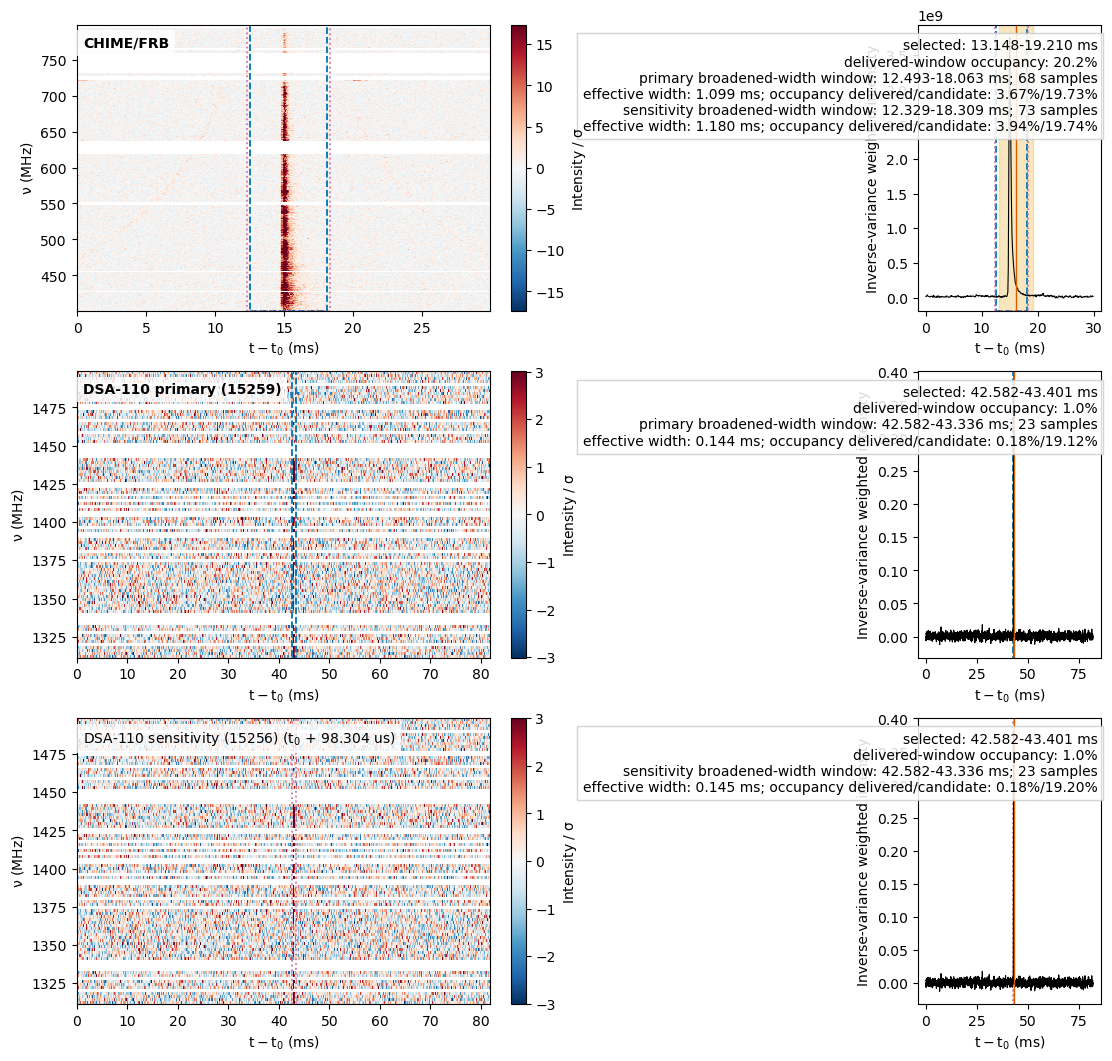

In [3]:
def channel_edges(centers):
    edges = np.empty(centers.size + 1)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])
    return edges

effective_windows = {
    'CHIME/FRB': [('primary', 153, 221, 1.098901, 0.03665, 0.19727), ('sensitivity', 151, 224, 1.180452, 0.03937, 0.19739)],
    'DSA-110 primary (15259)': [('primary', 1300, 1323, 0.144072, 0.0017587, 0.19116)],
    'DSA-110 sensitivity (15256)': [('sensitivity', 1300, 1323, 0.144682, 0.0017661, 0.19197)],
}
window_styles = {'primary': ('#0072b2', '--'), 'sensitivity': ('#cc79a7', ':')}

fig, axes = plt.subplots(3, 2, figsize=(11, 10.5), gridspec_kw={'width_ratios': (2.25, 1)}, constrained_layout=True)
for row, (label, band) in enumerate(bands.items()):
    instrument = str(band['instrument'])
    component = components[instrument]
    waterfall = band['waterfall'].astype(float)
    valid = band['pixel_valid'].astype(bool)
    noise = band['noise_std'].astype(float)
    if noise.ndim == 1:
        noise = noise[:, None]
    dt = float(band['sample_interval_s'])
    nfrequency, ntime = waterfall.shape
    time_centers_ms = np.arange(ntime) * dt * 1e3
    time_edges_ms = (np.arange(ntime + 1) - 0.5) * dt * 1e3
    frequency_edges = channel_edges(band['frequency_mhz'])
    displayed = np.where(valid, waterfall / noise, np.nan)
    finite = np.abs(displayed[np.isfinite(displayed)])
    limit = max(float(np.quantile(finite, 0.995)), 1.0)
    image = axes[row, 0].pcolormesh(time_edges_ms, frequency_edges, displayed, shading='flat', cmap='RdBu_r', vmin=-limit, vmax=limit, rasterized=True)
    fig.colorbar(image, ax=axes[row, 0], label=r'Intensity / $\sigma$')
    axes[row, 0].set(xlabel=r'$t-t_0$ (ms)', ylabel=r'$\nu$ (MHz)')
    plot_label = label
    if 'sensitivity' in label:
        plot_label += r' ($t_0$ + 98.304 us)'
    axes[row, 0].text(0.015, 0.96, plot_label, transform=axes[row, 0].transAxes, va='top', fontweight='bold', bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'})

    inverse_variance = np.where(valid, noise**-2, 0.0)
    numerator = np.where(valid, waterfall * inverse_variance, 0.0).sum(axis=0)
    denominator = inverse_variance.sum(axis=0)
    profile = np.divide(numerator, denominator, out=np.full(ntime, np.nan), where=denominator > 0)
    lower_sample = component['center_sample'] - component['half_width_samples']
    upper_sample = component['center_sample'] + component['half_width_samples']
    lower_ms, upper_ms = np.array([lower_sample, upper_sample]) * dt * 1e3
    axes[row, 1].plot(time_centers_ms, profile, color='black', linewidth=0.8)
    axes[row, 1].axvspan(lower_ms, upper_ms, color='#e69f00', alpha=0.25)
    compact_lines = []
    for arm, start, stop, width_ms, delivered_occupancy, candidate_occupancy in effective_windows[label]:
        compact_lower_ms = (start - 0.5) * dt * 1e3
        compact_upper_ms = (stop - 0.5) * dt * 1e3
        color, linestyle = window_styles[arm]
        for axis in axes[row]:
            axis.axvspan(compact_lower_ms, compact_upper_ms, facecolor='none', edgecolor=color, linewidth=1.3, linestyle=linestyle)
        compact_lines.append(f'{arm} broadened-width window: {compact_lower_ms:.3f}-{compact_upper_ms:.3f} ms; {stop-start} samples\neffective width: {width_ms:.3f} ms; occupancy delivered/candidate: {delivered_occupancy:.2%}/{candidate_occupancy:.2%}')
    compact_text = '\n' + '\n'.join(compact_lines)
    axes[row, 1].axvline(component['center_sample'] * dt * 1e3, color='#d55e00', linewidth=1)
    axes[row, 1].set(xlabel=r'$t-t_0$ (ms)', ylabel='Inverse-variance weighted intensity')
    occupancy = (upper_sample - lower_sample) / ntime
    axes[row, 1].text(0.98, 0.95, f'selected: {lower_ms:.3f}-{upper_ms:.3f} ms\ndelivered-window occupancy: {occupancy:.1%}{compact_text}', transform=axes[row, 1].transAxes, va='top', ha='right', bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.8'})

plt.show()

## Band-specific broadened-width window check

The corrected effective width runs from the restored-posterior EMG model's left half-maximum crossing to its right 1/e crossing after native-band integration. Each candidate adds two effective widths of off-pulse margin on both sides and rounds outward to sample edges.

| Fit arm | Band | Slice | Effective width | Samples | Effective-width occupancy, delivered / candidate |
|---|---|---:|---:|---:|---:|
| Primary 15259 | CHIME/FRB | `[153:221]` | 1.098901 ms | 68 | 3.665% / 19.727% |
| Primary 15259 | DSA-110 | `[1300:1323]` | 0.144072 ms | 23 | 0.17587% / 19.116% |
| Sensitivity 15256 | CHIME/FRB | `[151:224]` | 1.180452 ms | 73 | 3.937% / 19.739% |
| Sensitivity 15256 | DSA-110 | `[1300:1323]` | 0.144682 ms | 23 | 0.17661% / 19.197% |

The observed-profile crossings are unique. DSA-110 agrees with the model within 0.6 sample. The CHIME/FRB observed right crossing is 5.6–6.8 samples earlier than the model, consistent with the known CHIME/FRB model inadequacy; this is a scientific ambiguity, not a multiple-crossing ambiguity.

At the posterior median, the omitted EMG kernel fraction is 1.74e-11–4.66e-11 and the gain-statistic reconstruction gives compact-minus-full log-likelihood differences of -4.30e-9 to -5.05e-9. The nearby 84th-percentile posterior points reach -1.12e-8 to -4.64e-8. Prior-low differences are about -2.3; prior-midpoint differences are +1714 to +1778; prior-high differences are +7533 to +7560; the alternating edge reaches +8275. The reconstruction includes both the omitted-support gain Gram term and data projection with measured data and noise power. Direct subtraction of the full total likelihood is cancellation-limited near 1e-7.

Real h17 medians improve from 29.34 to 1.99 ms for primary Gaussian and from 100.02 to 7.97 ms for primary EMG; sample-15256 improves from 29.74 to 2.16 ms and from 110.48 to 7.68 ms. Historical execution corresponds to 10.256 effective workers, 64.1% of the configured 16. With observed call counts and a 25% margin, the hypothetical fixed windows project to 30.75 minutes. A full-prior-safe conservative calculation, for which the safe compact fraction has not been established, projects to 419.36 minutes. The candidate fails the 1e-8 nearby likelihood check and the few-minute duration gate, so it is rejected.

The earlier component-interval and intrinsic-width crops were narrower diagnostics and are not the broadened-width proposal shown here.

## Owner crop proposal: visual vetting panel

The owner proposes redefining the delivered fit inputs so the burst occupies roughly one fifth of each band's time span. This panel zooms each dynamic spectrum to the candidate ~20%-occupancy window (the broadened-width slices above) and overlays the two physically binding margins:

- **DM sweep** (solid curves): where the component center lands across the band at the DM prior edges (±0.1 pc cm⁻³ about the product DM). The CHIME sweep is ~1.9 ms and is the dominant margin term; the DSA sweep is ~40 µs.
- **Scattering-tail extent** (dashed curve): component center + 3 intrinsic widths + 5 τ(ν), with τ(ν) from the restored sensitivity posterior medians (τ₁GHz = 1.54 µs, α = 4.58, both near the low prior rail — the posterior tail is tens of microseconds, so this margin is not binding at the posterior; it binds only if the τ prior review moves the rail).

A candidate window passes visual vetting when both overlays sit comfortably inside it at every frequency in the band.

**Ratified (owner, 2026-08-04):** CHIME `[153:221]` and DSA `[1300:1323]`, both fit arms. Decision record: `~/Data/Faber2026/review/casey-joint-fit-inputs/window-decision-ratified-20260804.json`. Sampler restart is authorized separately.


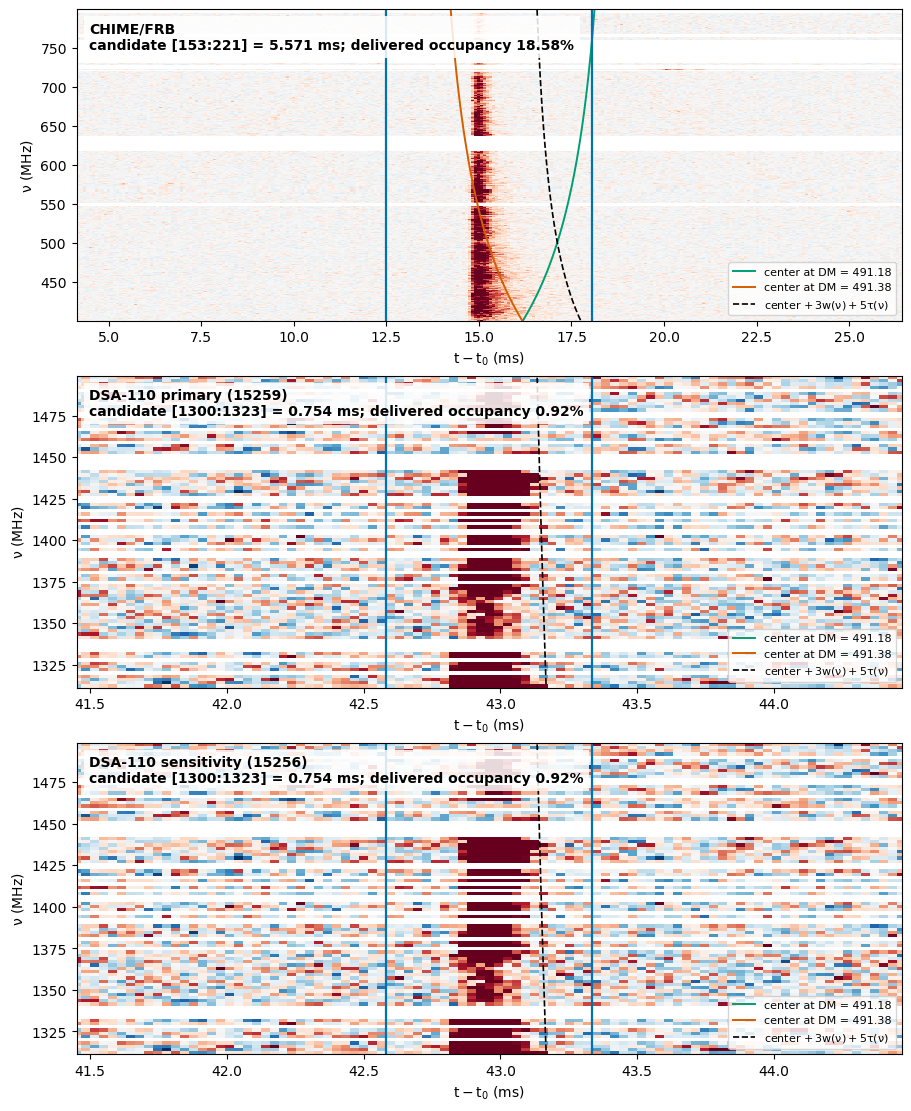

In [4]:
# Posterior medians from the restored sensitivity scattering run (fit-result.json / posterior.npz)
TAU_1GHZ_S = 1.53662e-06
SCATTERING_ALPHA = 4.57918
WIDTH_S = 3.5531e-04
WIDTH_INDEX = -1.53103
DM_PRIOR = tuple(config['joint_fit']['dm_bounds_pc_cm3'])

candidate_slices = {
    'CHIME/FRB': (153, 221),
    'DSA-110 primary (15259)': (1300, 1323),
    'DSA-110 sensitivity (15256)': (1300, 1323),
}

fig, axes = plt.subplots(3, 1, figsize=(9, 11), constrained_layout=True)
for axis, (label, band) in zip(axes, bands.items()):
    instrument = str(band['instrument'])
    component = components[instrument]
    waterfall = band['waterfall'].astype(float)
    valid = band['pixel_valid'].astype(bool)
    noise = band['noise_std'].astype(float)
    if noise.ndim == 1:
        noise = noise[:, None]
    dt = float(band['sample_interval_s'])
    ntime = waterfall.shape[1]
    start, stop = candidate_slices[label]
    window_ms = np.array([start - 0.5, stop - 0.5]) * dt * 1e3
    span = window_ms[1] - window_ms[0]
    view = (max(window_ms[0] - 1.5 * span, -0.5 * dt * 1e3),
            min(window_ms[1] + 1.5 * span, (ntime - 0.5) * dt * 1e3))
    time_edges_ms = (np.arange(ntime + 1) - 0.5) * dt * 1e3
    frequency = band['frequency_mhz']
    frequency_edges = channel_edges(frequency)
    displayed = np.where(valid, waterfall / noise, np.nan)
    finite = np.abs(displayed[np.isfinite(displayed)])
    limit = max(float(np.quantile(finite, 0.995)), 1.0)
    axis.pcolormesh(time_edges_ms, frequency_edges, displayed, shading='flat',
                    cmap='RdBu_r', vmin=-limit, vmax=limit, rasterized=True)

    center_ms = component['center_sample'] * dt * 1e3
    product_dm = float(band['product_dm_pc_cm3'])
    for edge_dm, color in ((DM_PRIOR[0], '#009e73'), (DM_PRIOR[1], '#d55e00')):
        sweep_ms = 4148.808 * (edge_dm - product_dm) * (frequency**-2.0 - 400.0**-2.0) * 1e3
        axis.plot(center_ms + sweep_ms, frequency, color=color, linewidth=1.4,
                  label=f'center at DM = {edge_dm}')
    tau_ms = TAU_1GHZ_S * (frequency / 1000.0) ** (-SCATTERING_ALPHA) * 1e3
    width_ms = WIDTH_S * (frequency / 400.0) ** WIDTH_INDEX * 1e3
    axis.plot(center_ms + 3 * width_ms + 5 * tau_ms, frequency, color='black',
              linestyle='--', linewidth=1.2, label=r'center $+\,3w(\nu)+5\tau(\nu)$')
    for boundary in window_ms:
        axis.axvline(boundary, color='#0072b2', linewidth=1.6)
    axis.set(xlim=view, xlabel=r'$t-t_0$ (ms)', ylabel=r'$\nu$ (MHz)')
    occupancy = (stop - start) / ntime
    axis.text(0.015, 0.96,
              f'{label}\ncandidate [{start}:{stop}] = {span:.3f} ms; delivered occupancy {occupancy:.2%}',
              transform=axis.transAxes, va='top', fontweight='bold',
              bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'none'})
    axis.legend(loc='lower right', fontsize=8)
plt.show()

## Actual initialization rules

There is no single optimizer start. Dynesty draws 600 live points in the unit cube with seed 20260729 and transforms each coordinate through the priors below. The listed unit-cube midpoint is a diagnostic reference point, not a special live point. Per-channel component amplitudes are not sampled: one gain per frequency channel is analytically marginalized under a fixed zero-mean Gaussian prior with variance 100.

In [5]:
K_DM = 4148.808
settings = config['joint_fit']
epoch_ns = int(geometry['epoch_unix_ns'])

def initialization_rows(dsa_label, morphology):
    selected = {'chime': bands['CHIME/FRB'], 'dsa': bands[dsa_label]}
    geocentric_bounds = {}
    for instrument, band in selected.items():
        component = components[instrument]
        dt = float(band['sample_interval_s'])
        center = (int(band['time0_unix_ns']) - epoch_ns) * 1e-9 + component['center_sample'] * dt - geometry['site_delay_s'][instrument]
        half_width = component['half_width_samples'] * dt
        geocentric_bounds[instrument] = (center - half_width, center + half_width)
    toa_bounds = (max(value[0] for value in geocentric_bounds.values()), min(value[1] for value in geocentric_bounds.values()))
    width_bounds = (
        max(components['chime']['width_bounds_s'][0], components['dsa']['width_bounds_s'][0]),
        min(components['chime']['width_bounds_s'][1], components['dsa']['width_bounds_s'][1]),
    )
    width_index_bounds = (
        max(components['chime']['width_index_bounds'][0], components['dsa']['width_index_bounds'][0]),
        min(components['chime']['width_index_bounds'][1], components['dsa']['width_index_bounds'][1]),
    )
    dm_bounds = settings['dm_bounds_pc_cm3']
    rows = [
        {'parameter': 'absolute DM (pc cm^-3)', 'prior': f'Uniform({dm_bounds[0]}, {dm_bounds[1]})', 'unit-cube midpoint': 0.5 * sum(dm_bounds)},
        {'parameter': 'geocentric unscattered ToA at 400 MHz (s from epoch)', 'prior': f'Uniform({toa_bounds[0]:.12f}, {toa_bounds[1]:.12f})', 'unit-cube midpoint': 0.5 * sum(toa_bounds)},
        {'parameter': 'intrinsic width (ms)', 'prior': f'LogUniform({width_bounds[0] * 1e3:.6f}, {width_bounds[1] * 1e3:.6f})', 'unit-cube midpoint': math.sqrt(width_bounds[0] * width_bounds[1]) * 1e3},
        {'parameter': 'width spectral index', 'prior': f'Uniform({width_index_bounds[0]}, {width_index_bounds[1]})', 'unit-cube midpoint': 0.5 * sum(width_index_bounds)},
    ]
    for instrument in ('chime', 'dsa'):
        sigma = math.hypot(geometry['site_delay_sigma_s'][instrument], geometry['clock_sigma_s'][instrument])
        rows.append({'parameter': f'{instrument} timing error (ms)', 'prior': f'Normal(0, {sigma * 1e3:.6f})', 'unit-cube midpoint': 0.0})
    if morphology == 'scattering':
        tau = settings['scattering_tau_1ghz_bounds_s']
        alpha = settings['scattering_alpha_bounds']
        rows.extend([
            {'parameter': 'tau at 1 GHz (ms)', 'prior': f'LogUniform({tau[0] * 1e3:.6f}, {tau[1] * 1e3:.6f})', 'unit-cube midpoint': math.sqrt(tau[0] * tau[1]) * 1e3},
            {'parameter': 'scattering spectral index', 'prior': f'Uniform({alpha[0]}, {alpha[1]})', 'unit-cube midpoint': 0.5 * sum(alpha)},
        ])
    return rows

tables = []
for arm, dsa_label in [('primary 15259', 'DSA-110 primary (15259)'), ('sensitivity 15256', 'DSA-110 sensitivity (15256)')]:
    for morphology in ('gaussian', 'scattering'):
        frame = pd.DataFrame(initialization_rows(dsa_label, morphology))
        frame.insert(0, 'fit', f'{arm}, {morphology}')
        tables.append(frame)
display(pd.concat(tables, ignore_index=True))

dm_midpoint = 0.5 * sum(settings['dm_bounds_pc_cm3'])
fixed = pd.DataFrame([
    {'quantity': 'reference frequency', 'value': '400 MHz'},
    {'quantity': 'component association', 'value': 'CHIME/FRB c1 matched to DSA-110 c1'},
    {'quantity': 'per-channel gains', 'value': 'Normal(0, variance 100), analytically marginalized'},
    {'quantity': 'Gaussian model', 'value': 'tau fixed to zero; no scattering spectral index'},
    {'quantity': 'primary residual DM at prior midpoint', 'value': f"CHIME/FRB {dm_midpoint - float(bands['CHIME/FRB']['product_dm_pc_cm3']):+.9f}; DSA-110 {dm_midpoint - float(bands['DSA-110 primary (15259)']['product_dm_pc_cm3']):+.9f} pc cm^-3"},
    {'quantity': 'sampler', 'value': f"Dynesty {settings['sampler']['sample']}, nlive={settings['sampler']['nlive']}, dlogz={settings['sampler']['dlogz']}, seed={settings['sampler']['seed']}"},
])
display(fixed)

,fit,parameter,prior,unit-cube midpoint
0,"primary 15259, gaussian",absolute DM (pc cm^-3),"Uniform(491.18, 491.38)",491.280000
1,"primary 15259, gaussian",geocentric unscattered ToA at 400 MHz (s from ...,"Uniform(11.885520675483, 11.886339875483)",11.885930
2,"primary 15259, gaussian",intrinsic width (ms),"LogUniform(0.348160, 0.409600)",0.377633
3,"primary 15259, gaussian",width spectral index,"Uniform(-2.0, 2.0)",0.000000
4,"primary 15259, gaussian",chime timing error (ms),"Normal(0, 0.707107)",0.000000
5,"primary 15259, gaussian",dsa timing error (ms),"Normal(0, 0.707107)",0.000000
6,"primary 15259, scattering",absolute DM (pc cm^-3),"Uniform(491.18, 491.38)",491.280000
7,"primary 15259, scattering",geocentric unscattered ToA at 400 MHz (s from ...,"Uniform(11.885520675483, 11.886339875483)",11.885930
8,"primary 15259, scattering",intrinsic width (ms),"LogUniform(0.348160, 0.409600)",0.377633
9,"primary 15259, scattering",width spectral index,"Uniform(-2.0, 2.0)",0.000000


,quantity,value
0,reference frequency,400 MHz
1,component association,CHIME/FRB c1 matched to DSA-110 c1
2,per-channel gains,"Normal(0, variance 100), analytically marginal..."
3,Gaussian model,tau fixed to zero; no scattering spectral index
4,primary residual DM at prior midpoint,CHIME/FRB +0.000000000; DSA-110 +0.000000000 p...
5,sampler,"Dynesty rwalk, nlive=600, dlogz=0.5, seed=2026..."


## Interpretation

The orange intervals are the reviewed component regions. The blue dashed and purple dotted outlines are the primary and sample-15256 band-specific broadened-width windows. They achieve approximately 20% effective-width occupancy, but they are not accepted computational crops: nearby posterior likelihood differences exceed 1e-8, broad-prior differences are much larger, and the pool-efficiency-corrected duration remains above the target. The full products remain the fit inputs.